# agentv9_parallel_workflow — Parallel Branches

This version introduces fan-out / fan-in execution.

Graph:

```text
              ┌→ failure_analysis ┐
START → split ├→ latency_analysis ├→ synthesize → END
              └→ volume_analysis  ┘
```

This is useful when a task can be decomposed into independent analyses.


## 1. Install dependencies

```bash
pip install -U langgraph langchain langchain-openai langsmith python-dotenv ipython jupyter
```


In [1]:
# Optional: uncomment in a fresh environment.
# %pip install -U langgraph langchain langchain-openai langsmith python-dotenv ipython jupyter


## 2. Load environment variables


In [2]:
from pathlib import Path
import os
from dotenv import load_dotenv

cwd = Path.cwd()
load_dotenv(cwd / ".env")
load_dotenv(cwd.parent / ".env")

print("OpenAI API key present:", bool(os.getenv("OPENAI_API_KEY")))
print("LangSmith tracing:", os.getenv("LANGSMITH_TRACING"))
print("LangSmith project:", os.getenv("LANGSMITH_PROJECT"))


OpenAI API key present: True
LangSmith tracing: true
LangSmith project: langgraph-playground


## 3. Define state with reducer

Parallel branches may update the same field.

Here each branch writes to `analysis_results`.

So we need a reducer:

```python
analysis_results: Annotated[list[str], operator.add]
```

This tells LangGraph to concatenate lists from parallel branches.


In [3]:
import operator
from typing import Annotated, TypedDict

class AgentState(TypedDict, total=False):
    input: str
    analysis_results: Annotated[list[str], operator.add]
    final_answer: str


## 4. Define split node

The split node is the fan-out point.

It does not do much work. It prepares the shared state.


In [4]:
def split_node(state: AgentState) -> AgentState:
    return {"analysis_results": []}


## 5. Define parallel branch nodes


In [5]:
def failure_analysis_node(state: AgentState) -> AgentState:
    return {
        "analysis_results": [
            "Failure analysis: CONNECTION_TIMEOUT is the dominant failure reason after the release window."
        ]
    }

def latency_analysis_node(state: AgentState) -> AgentState:
    return {
        "analysis_results": [
            "Latency analysis: response_time increased during the release window, especially for CHECK-DOMAIN."
        ]
    }

def volume_analysis_node(state: AgentState) -> AgentState:
    return {
        "analysis_results": [
            "Volume analysis: CHECK-DOMAIN failure volume increased more than other commands."
        ]
    }


## 6. Define synthesis node

The synthesis node combines all branch outputs and writes the final answer.

This version uses a real OpenAI LLM for synthesis.


In [6]:
from langchain_openai import ChatOpenAI

def synthesize_node(state: AgentState) -> AgentState:
    llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

    joined = "\n".join(f"- {item}" for item in state["analysis_results"])

    prompt = f'''
User request:
{state["input"]}

Independent analysis results:
{joined}

Write a concise executive summary with:
1. overall health
2. likely root cause
3. recommended next action
'''

    response = llm.invoke(prompt)
    return {"final_answer": response.content}


## 7. Build graph


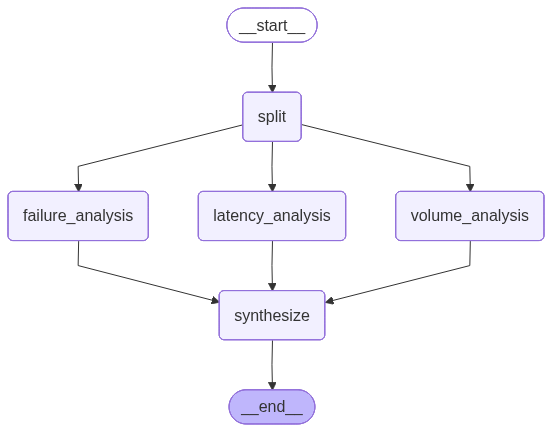

In [7]:
from langgraph.graph import START, END, StateGraph

def build_graph():
    g = StateGraph(AgentState)

    g.add_node("split", split_node)
    g.add_node("failure_analysis", failure_analysis_node)
    g.add_node("latency_analysis", latency_analysis_node)
    g.add_node("volume_analysis", volume_analysis_node)
    g.add_node("synthesize", synthesize_node)

    g.add_edge(START, "split")

    # Fan out
    g.add_edge("split", "failure_analysis")
    g.add_edge("split", "latency_analysis")
    g.add_edge("split", "volume_analysis")

    # Fan in
    g.add_edge("failure_analysis", "synthesize")
    g.add_edge("latency_analysis", "synthesize")
    g.add_edge("volume_analysis", "synthesize")

    g.add_edge("synthesize", END)

    return g.compile()

graph = build_graph()
graph


## 8. Visualize Mermaid graph


In [8]:
print(graph.get_graph().draw_mermaid())


---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	split(split)
	failure_analysis(failure_analysis)
	latency_analysis(latency_analysis)
	volume_analysis(volume_analysis)
	synthesize(synthesize)
	__end__([<p>__end__</p>]):::last
	__start__ --> split;
	failure_analysis --> synthesize;
	latency_analysis --> synthesize;
	split --> failure_analysis;
	split --> latency_analysis;
	split --> volume_analysis;
	volume_analysis --> synthesize;
	synthesize --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



## 9. Visualize PNG graph


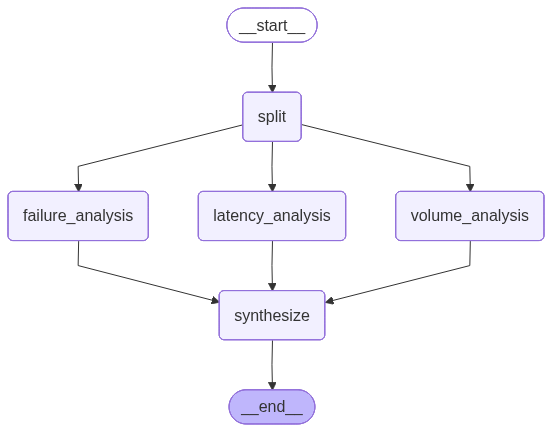

In [9]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print("PNG rendering failed.")
    print("Reason:", e)


## 10. Execute parallel workflow


In [10]:
result = graph.invoke({
    "input": "Analyze EPP SLA health for the latest release."
})

result


{'input': 'Analyze EPP SLA health for the latest release.',
 'analysis_results': ['Failure analysis: CONNECTION_TIMEOUT is the dominant failure reason after the release window.',
  'Latency analysis: response_time increased during the release window, especially for CHECK-DOMAIN.',
  'Volume analysis: CHECK-DOMAIN failure volume increased more than other commands.'],
 'final_answer': '**Executive Summary: EPP SLA Health Analysis for Latest Release**\n\n1. **Overall Health**: The EPP SLA health has deteriorated following the latest release, with a significant increase in failure rates and response times, particularly for the CHECK-DOMAIN command.\n\n2. **Likely Root Cause**: The primary issue appears to be related to CONNECTION_TIMEOUT errors, which have surged post-release. This, coupled with increased response times during the release window, suggests potential performance degradation or resource constraints affecting the CHECK-DOMAIN functionality.\n\n3. **Recommended Next Action**: I

## 11. Inspect branch outputs


In [11]:
for item in result["analysis_results"]:
    print("-", item)


- Failure analysis: CONNECTION_TIMEOUT is the dominant failure reason after the release window.
- Latency analysis: response_time increased during the release window, especially for CHECK-DOMAIN.
- Volume analysis: CHECK-DOMAIN failure volume increased more than other commands.


## 12. Inspect final synthesis


In [12]:
print(result["final_answer"])


**Executive Summary: EPP SLA Health Analysis for Latest Release**

1. **Overall Health**: The EPP SLA health has deteriorated following the latest release, with a significant increase in failure rates and response times, particularly for the CHECK-DOMAIN command.

2. **Likely Root Cause**: The primary issue appears to be related to CONNECTION_TIMEOUT errors, which have surged post-release. This, coupled with increased response times during the release window, suggests potential performance degradation or resource constraints affecting the CHECK-DOMAIN functionality.

3. **Recommended Next Action**: Immediate investigation into the underlying infrastructure and code changes related to the CHECK-DOMAIN command is essential. Implementing performance monitoring and optimization measures, along with a rollback plan if necessary, should be prioritized to restore service reliability and meet SLA commitments.


## 13. Why this matters

This pattern is useful when one question requires independent analysis streams.

Examples:

```text
CloudOps incident:
  logs_analysis
  metrics_analysis
  config_analysis
  synthesize

BI report:
  failures_analysis
  latency_analysis
  volume_analysis
  synthesize

RAG:
  policy_docs
  runbooks
  tickets
  synthesize
```

This is different from v8.

v8 loops when each next step depends on previous output.

v9 runs branches independently and merges them.


## 14. LangSmith trace

Open project:

```text
langgraph-playground
```

Expected trace:

```text
Graph run
  ├── split
  ├── failure_analysis
  ├── latency_analysis
  ├── volume_analysis
  └── synthesize
        └── ChatOpenAI
```

Parallel branches should appear as separate sibling runs before synthesis.
